In [796]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import linregress

In [797]:
def read_df(path):
    df = pd.read_csv(path, header=None)
    cols = [x.split(":")[0] for x in df.iloc[0]]
    df.columns = cols
    for col in cols:
        df[col] = df[col].str.split(":").str[1]
        df[col] = pd.to_numeric(df[col])
    return df

In [798]:
def clamp_diff(series, diff):
    result = series.copy()
    for i in range(1, len(result)):
        if result.iloc[i] > result.iloc[i-1] + diff:
            result.iloc[i] = result.iloc[i-1] + diff
        elif result.iloc[i] < result.iloc[i-1] - diff:
            result.iloc[i] = result.iloc[i-1] - diff
    return result

In [799]:
baseline = read_df("final-baselines.csv")
del baseline["Distance"]
baseline

,TEMT6000,LDR
0,0,2
1,0,3
2,0,4
3,0,4
4,0,3
...,...,...
316,0,0
317,0,1
318,0,0
319,0,0


Text(0.5, 1.0, 'Avstand over tid')

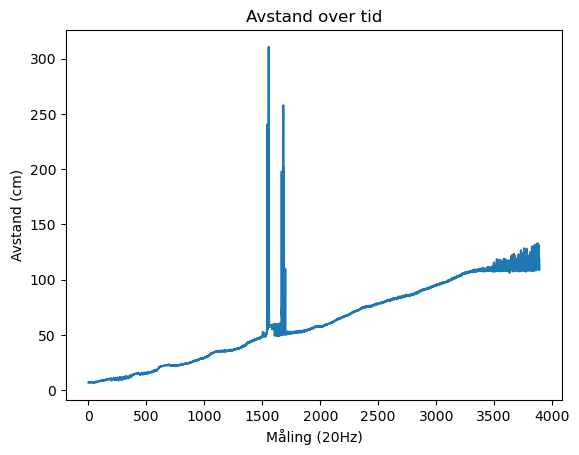

In [800]:
#| label: distance-raw
df = read_df("final1.csv")
df["Distance"].plot()
plt.xlabel("Måling (20Hz)")
plt.ylabel("Avstand (cm)")
plt.title("Avstand over tid")

,TEMT6000,LDR,Distance,R_LDR,LDR_Linearized
0,1003,1021,6.89,117.531832,1.103151e-03
1,1005,1020,6.87,176.470588,6.172599e-04
2,1004,1021,6.89,117.531832,1.103151e-03
3,1002,1022,6.93,58.708415,2.973618e-03
4,1003,1020,6.97,176.470588,6.172599e-04
...,...,...,...,...,...
3886,5,686,113.43,29475.218659,4.121558e-07
3887,6,686,113.47,29475.218659,4.121558e-07
3888,4,686,113.43,29475.218659,4.121558e-07
3889,4,686,113.39,29475.218659,4.121558e-07


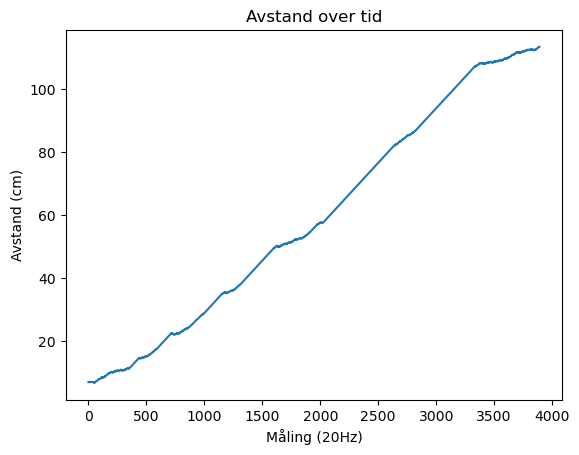

In [933]:
#| label: distance-clamped
#df = read_df("dark-flashlight3-long-slow.csv") # Closest to linear
#df = read_df("dark-flashlight5.csv") # 3.
#df = read_df("dark-flashlight2-long.csv") # 2.
#df = read_df("dark-flashlight1.csv") # 4.

# === NEW DATASETS ===

def read(name, diff):
    df = read_df(name)
    df["Distance"] = clamp_diff(df["Distance"], diff)
    return df

df = read("final1.csv", 0.04)
#df["Distance"] = df["Distance"].astype(int)
#df = read("final2.csv", 0.2)
#df = read("final4.csv", 0.2)
#df = read("final5.csv", 0.25)

resistance = 60_000 # 60 kΩ
df["R_LDR"] = resistance * ((1023 / df["LDR"]) - 1)
alpha = 0.7
df["LDR_Linearized"] = 1 / (df["R_LDR"] ** (1 / alpha))

#df.iloc[1075:1150].reset_index().plot(x="index", y="Distance", kind="scatter")
df["Distance"].plot()

plt.xlabel("Måling (20Hz)")
plt.ylabel("Avstand (cm)")
plt.title("Avstand over tid")
df

Text(0.5, 1.0, 'Raw LDR ADC value by distance')

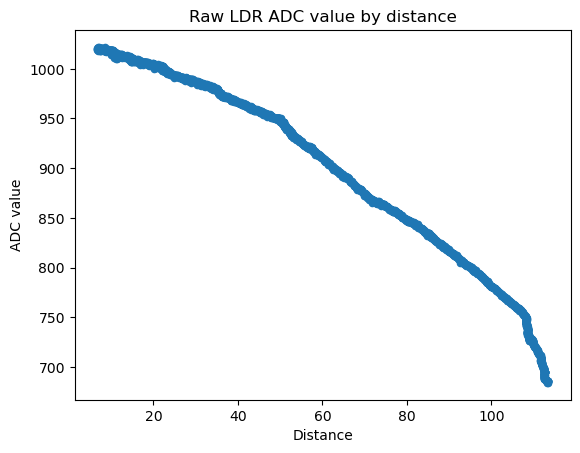

In [934]:
#| label: raw-ldr
df.plot(x="Distance", y="LDR", kind="scatter")
plt.ylabel("ADC value")
plt.title("Raw LDR ADC value by distance")

Text(0.5, 1.0, 'LDR Resistance by distance')

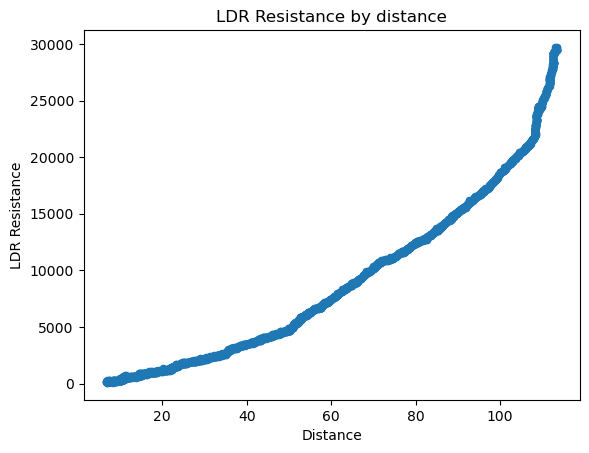

In [935]:
#| label: raw-ldr-r
df.plot(x="Distance", y="R_LDR", kind="scatter")
plt.ylabel("LDR Resistance")
plt.title("LDR Resistance by distance")

Verdi: 2.0 ± 2.0
Gjennomsnitt: 0.355
LDR = 0.4 ± 2.0
Intervallstørrelse: 338
Variasjonsbredde = 4 ~ 0.59% av intervall
Standardavvik: 0.7655
Standardfeil: 0.0427


Text(0.5, 1.0, 'Lysintensitet i mørkt rom (fotoresistor)')

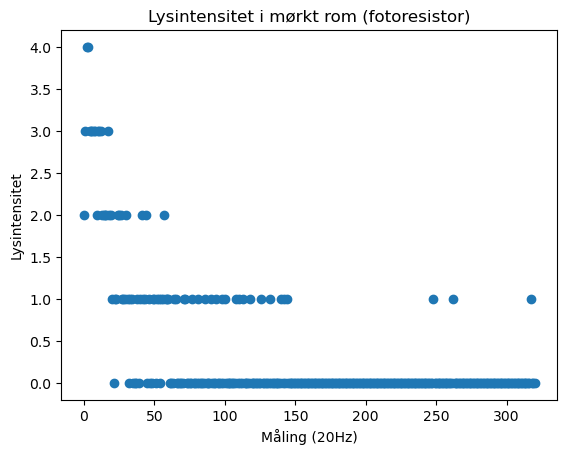

In [936]:
#| label: baseline-ldr

ldr = baseline["LDR"]
ldr_range = df["LDR"].max() - df["LDR"].min()
variasjon = ldr.max() - ldr.min()
avvik = variasjon / 2
avvik_forhold = avvik / ldr_range * 100
ldr_baseline = ldr.mean()
mid = ldr.min() + variasjon / 2
print(f"Verdi: {mid:.1f} ± {avvik:.1f}")
print(f"Gjennomsnitt: {ldr.mean():.3f}")
print(f"LDR = {ldr_baseline:.1f} ± {avvik:.1f}")
print(f"Intervallstørrelse: {ldr_range}")
print(f"Variasjonsbredde = {variasjon} ~ {avvik_forhold:.2f}% av intervall")
print(f"Standardavvik: {ldr.std():.4f}")
print(f"Standardfeil: {ldr.sem():.4f}")

plt.scatter(baseline.index, baseline["LDR"])
plt.xlabel("Måling (20Hz)")
plt.ylabel("Lysintensitet")
plt.title("Lysintensitet i mørkt rom (fotoresistor)")

Verdi: 0.5 ± 0.5
Gjennomsnitt: 0.003
Intervallstørrelse: 1001
Variasjonsbredde = 1 ~ 0.05% av intervall
Standardavvik: 0.0558
Standardfeil: 0.0031


Text(0.5, 1.0, 'Lysintensitet i mørkt rom (TEMT6000)')

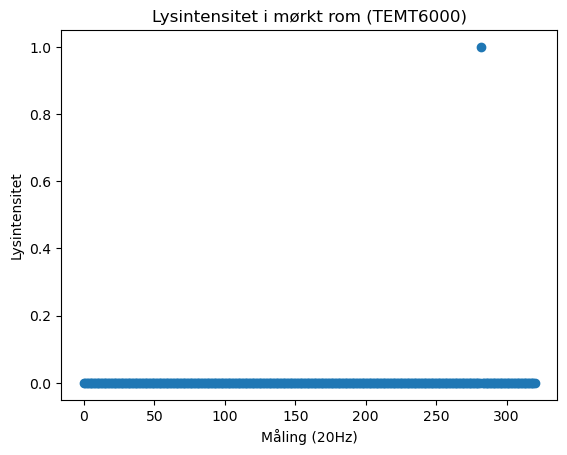

In [937]:
#| label: baseline-temt
temt = baseline["TEMT6000"]
temt_range = df["TEMT6000"].max() - df["TEMT6000"].min()
variasjon = temt.max() - temt.min()
avvik = variasjon / 2
avvik_forhold = avvik / temt_range * 100
temt_baseline = temt.mean()
mid = temt.min() + variasjon / 2
print(f"Verdi: {mid:.1f} ± {avvik:.1f}")
print(f"Gjennomsnitt: {temt.mean():.3f}")
print(f"Intervallstørrelse: {temt_range}")
print(f"Variasjonsbredde = {variasjon} ~ {avvik_forhold:.2f}% av intervall")
print(f"Standardavvik: {temt.std():.4f}")
print(f"Standardfeil: {temt.sem():.4f}")

plt.scatter(baseline.index, baseline["TEMT6000"])
plt.xlabel("Måling (20Hz)")
plt.ylabel("Lysintensitet")
plt.title("Lysintensitet i mørkt rom (TEMT6000)")

Text(0.5, 1.0, 'Intensitet etter avstand (TEMT6000)')

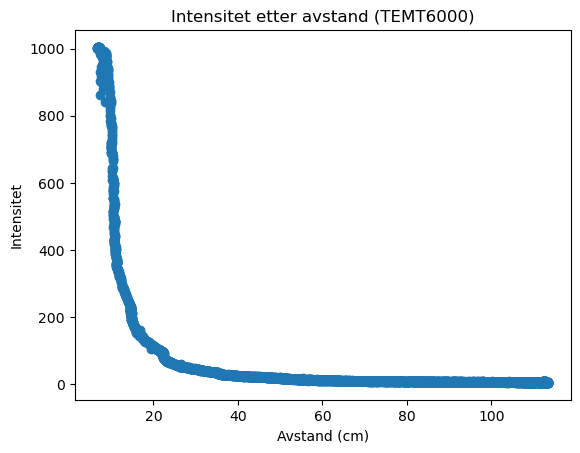

In [938]:
#| label: temt-raw-scatter
plt.scatter(df["Distance"], df["TEMT6000"])
plt.xlabel("Avstand (cm)")
plt.ylabel("Intensitet")
plt.title("Intensitet etter avstand (TEMT6000)")

Text(0.5, 1.0, 'Linearized plot of intensity vs distance')

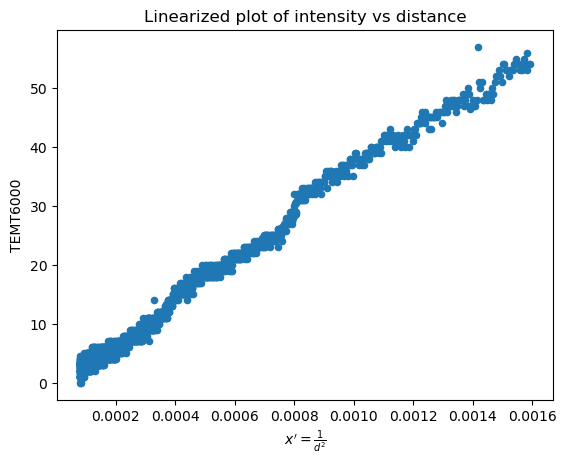

In [939]:
#| label: df-grouped
df2 = df.groupby("Distance").mean()
df2["TEMT6000"] -= df2["TEMT6000"].min()
df2["LDR"] -= df2["LDR"].min()
df2 = df2[(df2.index >= 25)]
df2["x2"] = 1 / (df2.index ** 2)

df2.plot(x=r"x2", y="TEMT6000", kind="scatter")
plt.xlabel(r"$x'=\frac{1}{d^2}$")
plt.title("Linearized plot of intensity vs distance")

In [940]:
a, b, r, _, _ = linregress(df2["x2"], df2["TEMT6000"])
print(f"f(x) = ax + b ≈ {a:.0f}x - {-b:.3f}")
print(f"R^2 = {r**2:.3f}")

f(x) = ax + b ≈ 36599x - 0.891
R^2 = 0.992


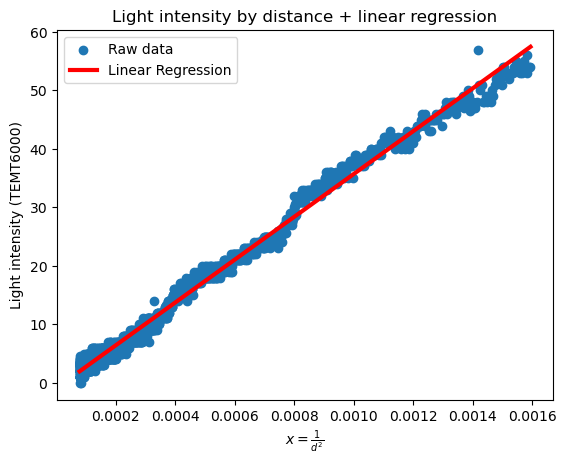

In [941]:
#| label: temt-linear-regression

fig, ax = plt.subplots()

xs = df2["x2"]
ys = a * df2["x2"] + b

ax.scatter(xs, df2["TEMT6000"], label="Raw data")
ax.plot(df2["x2"], ys, color="red", label="Linear Regression", linewidth=3)

ax.set_xlabel(r"$x=\frac{1}{d^2}$")
ax.set_ylabel("Light intensity (TEMT6000)")
ax.set_title("Light intensity by distance + linear regression")
ax.legend()

In [942]:
log_d = np.log(df2.index.values)
log_temt = np.log(df2["TEMT6000"].values - b)

a_log, _ = np.polyfit(log_d, log_temt, 1)

print(f"Exponent ≈ {slope_log:.3f}")

Exponent ≈ -1.994


Text(0.5, 1.0, 'LDR by distance')

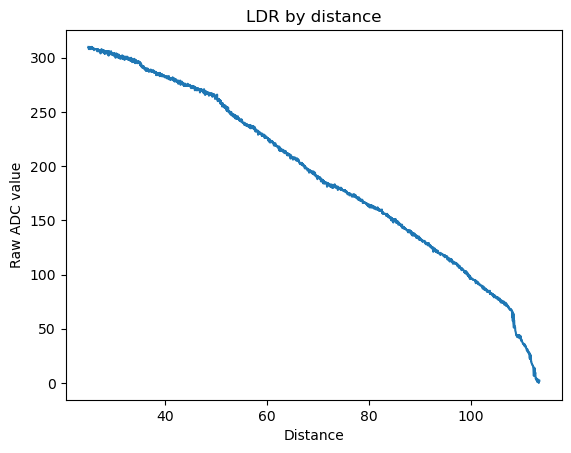

In [943]:
#| label: ldr-plot-1
df2["LDR"].plot()
plt.ylabel("Raw ADC value")
plt.title("LDR by distance")

Text(0.5, 1.0, 'Linearized LDR by distance')

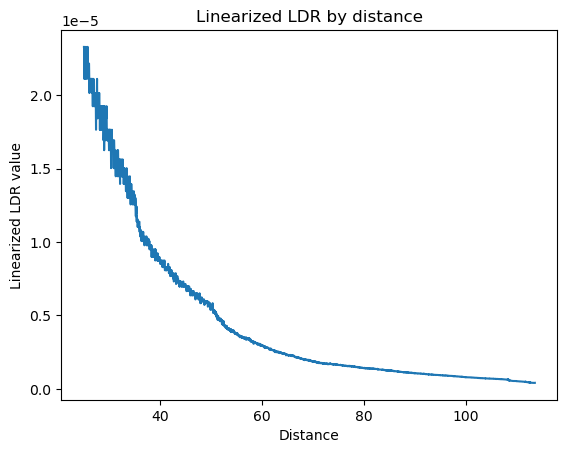

In [944]:
#| label: ldr-plot-2
#df2.reset_index().plot(x="index", y="LDR_Linearized", kind="scatter")
df2["LDR_Linearized"].plot()
plt.ylabel("Linearized LDR value")
plt.title("Linearized LDR by distance")

Text(0.5, 1.0, 'Linearized plot of intensity vs distance')

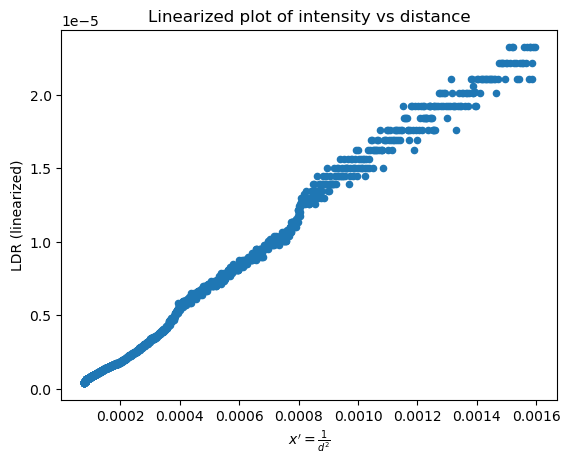

In [945]:
#| label: ldr-scatter-1
df2.plot(x="x2", y="LDR_Linearized", kind="scatter")
plt.ylabel("LDR (linearized)")
plt.xlabel(r"$x'=\frac{1}{d^2}$")
plt.title("Linearized plot of intensity vs distance")

In [946]:
a, b, r, _, _ = linregress(df2["x2"], df2["LDR_Linearized"])
print(f"f(x) = ax + b ≈ {a:.0f}x - {-b:.3f}")
print(f"R^2 = {r**2:.3f}")

f(x) = ax + b ≈ 0x - 0.000
R^2 = 0.994


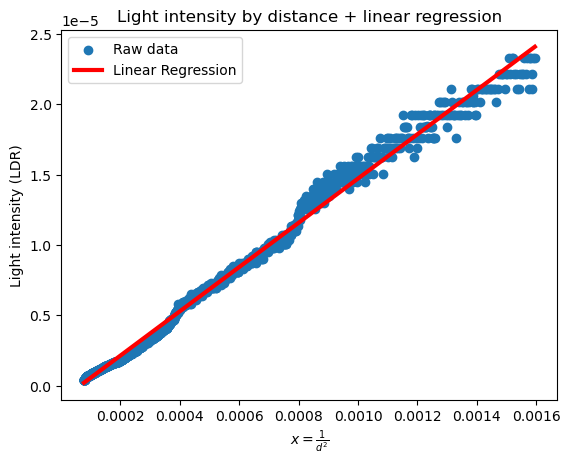

In [947]:
#| label: ldr-linear-regression

fig, ax = plt.subplots()

xs = df2["x2"]
ys = a * df2["x2"] + b

ax.scatter(xs, df2["LDR_Linearized"], label="Raw data")
ax.plot(df2["x2"], ys, color="red", label="Linear Regression", linewidth=3)

ax.set_xlabel(r"$x=\frac{1}{d^2}$")
ax.set_ylabel("Light intensity (LDR)")
ax.set_title("Light intensity by distance + linear regression")
ax.legend()

In [948]:
log_d = np.log(df2.index.values)
log_temt = np.log(df2["LDR_Linearized"].values - b)

a_log, _ = np.polyfit(log_d, log_temt, 1)

print(f"Exponent ≈ {slope_log:.3f}")

Exponent ≈ -1.994
